In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [12]:
performance_summary = pd.read_csv(
    "../results/main_model_performance_table.csv"
)

print("Performance summary loaded.")
print(performance_summary)

Performance summary loaded.
           Model  ROC_AUC_Mean  ROC_AUC_SD  PR_AUC_Mean  PR_AUC_SD  \
0            EBM        0.7410      0.0558       0.2913     0.0778   
1  Random Forest        0.7333      0.0385       0.2561     0.0547   
2        XGBoost        0.6836      0.0379       0.2087     0.0348   

   Balanced_Accuracy_Mean  Balanced_Accuracy_SD  Recall_Mean  Recall_SD  \
0                  0.5000                0.0000       0.0000     0.0000   
1                  0.6372                0.0418       0.4714     0.0754   
2                  0.6059                0.0325       0.4112     0.0711   

   F1_Mean   F1_SD  
0   0.0000  0.0000  
1   0.3223  0.0500  
2   0.2848  0.0394  


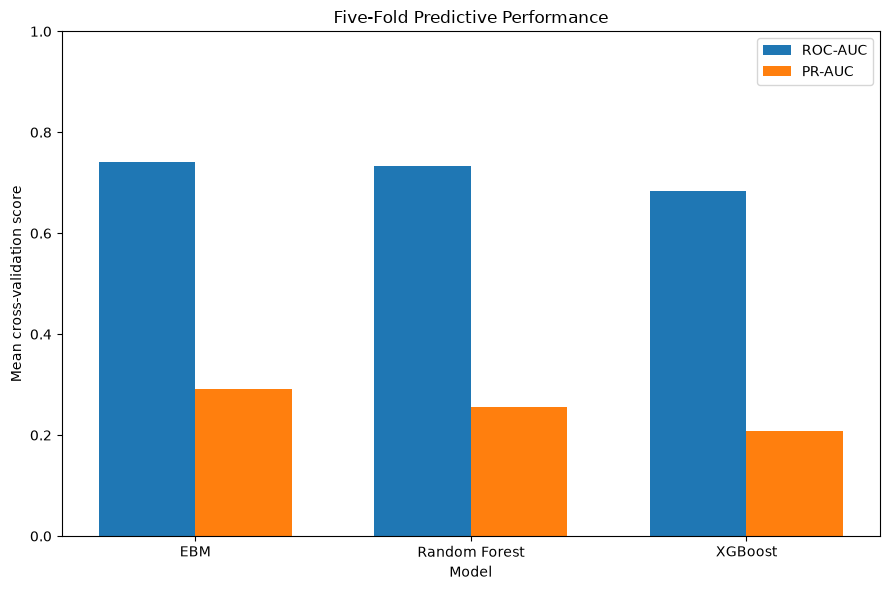

In [13]:
models = performance_summary["Model"].tolist()

roc_auc = performance_summary["ROC_AUC_Mean"].tolist()
pr_auc = performance_summary["PR_AUC_Mean"].tolist()

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

ax.bar(
    x - width/2,
    roc_auc,
    width,
    label="ROC-AUC"
)

ax.bar(
    x + width/2,
    pr_auc,
    width,
    label="PR-AUC"
)

ax.set_xlabel("Model")
ax.set_ylabel("Mean cross-validation score")
ax.set_title("Five-Fold Predictive Performance")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()

plt.savefig(
    "../results/model_performance_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
stability_summary = pd.read_csv(
    "../results/attribution_stability_summary.csv"
)

print("Attribution stability data loaded.")
print(stability_summary.head(10))

Attribution stability data loaded.
           Model   Feature    Mean      SD      CV
0            EBM       AGE  0.1228  0.0297  0.2417
1            EBM      APOE  0.0915  0.0123  0.1343
2            EBM  CDGLOBAL  0.0294  0.0048  0.1627
3            EBM     CDRSB  0.2667  0.0479  0.1797
4            EBM   MMSCORE  0.2631  0.0355  0.1349
5            EBM  PTEDUCAT  0.0324  0.0184  0.5699
6            EBM  PTETHCAT  0.0086  0.0031  0.3564
7            EBM  PTGENDER  0.0251  0.0078  0.3114
8            EBM  PTRACCAT  0.0248  0.0023  0.0945
9  Random Forest       AGE  0.0533  0.0065  0.1213


In [15]:
primary_features = [
    "AGE",
    "PTGENDER",
    "PTEDUCAT",
    "PTETHCAT",
    "PTRACCAT",
    "APOE",
    "CDGLOBAL",
    "CDRSB",
    "MMSCORE"
]

attribution_comparison = (
    stability_summary
    .pivot(
        index="Feature",
        columns="Model",
        values="Mean"
    )
    .reindex(primary_features)
    .reset_index()
)

print("Cross-model attribution comparison:")
print(attribution_comparison.round(4))

Cross-model attribution comparison:
Model   Feature     EBM  Random Forest  XGBoost
0           AGE  0.1228         0.0533   0.7087
1      PTGENDER  0.0251         0.0092   0.0537
2      PTEDUCAT  0.0324         0.0246   0.2647
3      PTETHCAT  0.0086         0.0010   0.0128
4      PTRACCAT  0.0248         0.0028   0.0246
5          APOE  0.0915         0.0187   0.1329
6      CDGLOBAL  0.0294         0.0024   0.0190
7         CDRSB  0.2667         0.0927   0.6106
8       MMSCORE  0.2631         0.0940   0.6480


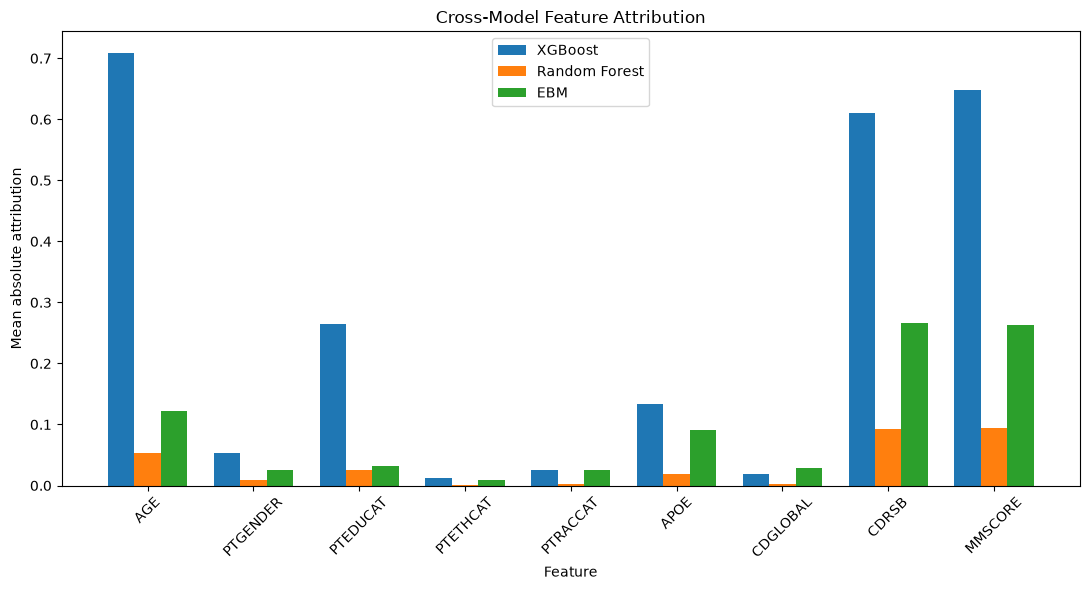

In [16]:
plot_data = attribution_comparison.set_index("Feature")

fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(plot_data))
width = 0.25

ax.bar(
    x - width,
    plot_data["XGBoost"],
    width,
    label="XGBoost"
)

ax.bar(
    x,
    plot_data["Random Forest"],
    width,
    label="Random Forest"
)

ax.bar(
    x + width,
    plot_data["EBM"],
    width,
    label="EBM"
)

ax.set_xlabel("Feature")
ax.set_ylabel("Mean absolute attribution")
ax.set_title("Cross-Model Feature Attribution")
ax.set_xticks(x)
ax.set_xticklabels(plot_data.index, rotation=45)
ax.legend()

plt.tight_layout()

plt.savefig(
    "../results/cross_model_attribution_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [17]:
final_xai_summary = pd.read_csv(
    "../results/final_xai_summary.csv"
)

print("Final XAI summary loaded.")
print(final_xai_summary)


Final XAI summary loaded.
                                    Analysis   Value
0  XGBoost vs Random Forest rank correlation  0.9500
1            XGBoost vs EBM rank correlation  0.8667
2      Random Forest vs EBM rank correlation  0.9167
3                    Top-3 all-model Jaccard  1.0000
4                    Top-5 all-model Jaccard  1.0000
5         XGBoost within-fold rank stability  0.9417
6   Random Forest within-fold rank stability  0.9800
7             EBM within-fold rank stability  0.8883


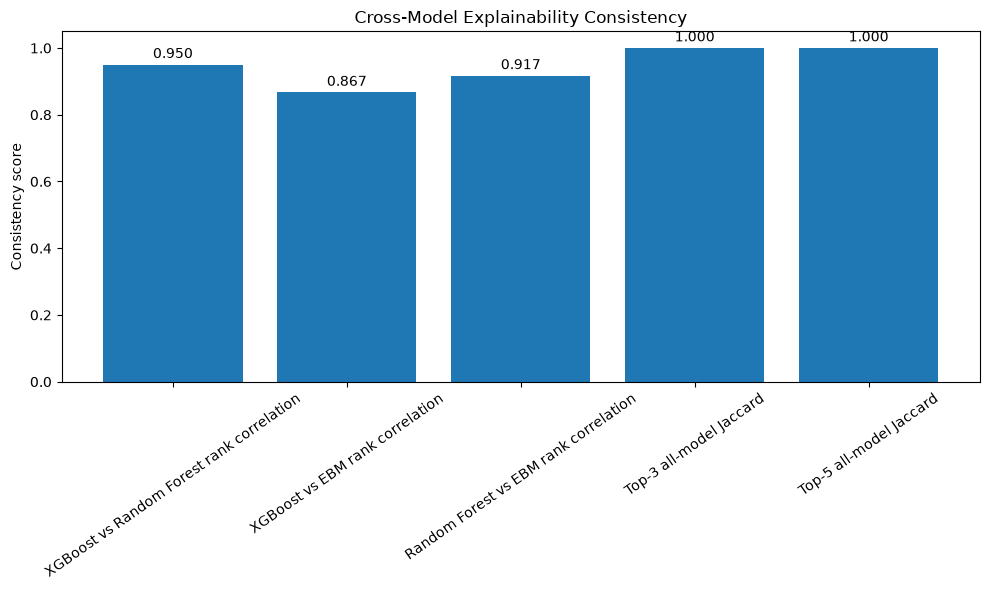

In [18]:
consistency_data = final_xai_summary[
    final_xai_summary["Analysis"].str.contains(
        "rank correlation|Jaccard",
        regex=True
    )
].copy()

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    consistency_data["Analysis"],
    consistency_data["Value"]
)

ax.set_ylabel("Consistency score")
ax.set_title("Cross-Model Explainability Consistency")
ax.set_ylim(0, 1.05)

ax.tick_params(
    axis="x",
    rotation=35
)

for bar, value in zip(bars, consistency_data["Value"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "../results/xai_consistency_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

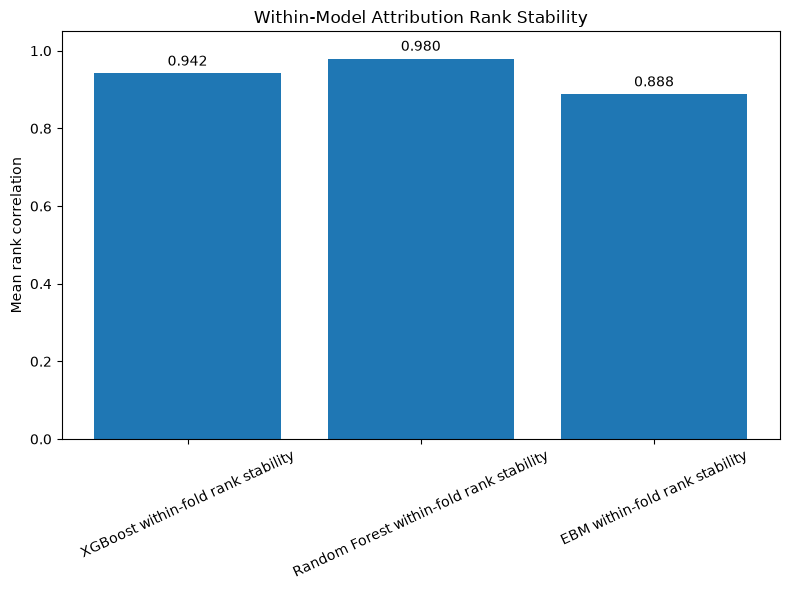

In [19]:
stability_data = final_xai_summary[
    final_xai_summary["Analysis"].str.contains(
        "within-fold rank stability"
    )
].copy()

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    stability_data["Analysis"],
    stability_data["Value"]
)

ax.set_ylabel("Mean rank correlation")
ax.set_title("Within-Model Attribution Rank Stability")
ax.set_ylim(0, 1.05)

ax.tick_params(
    axis="x",
    rotation=25
)

for bar, value in zip(bars, stability_data["Value"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "../results/xai_stability_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
final_xai_summary.to_csv(
    "../results/final_xai_summary_for_paper.csv",
    index=False
)

print("Final XAI summary for paper saved.")

Final XAI summary for paper saved.


In [21]:
final_model_results = performance_summary[
    [
        "Model",
        "ROC_AUC_Mean",
        "ROC_AUC_SD",
        "PR_AUC_Mean",
        "PR_AUC_SD",
        "Balanced_Accuracy_Mean",
        "Recall_Mean",
        "F1_Mean"
    ]
].copy()

final_model_results = final_model_results.round(4)

print("Final model comparison:")
print(final_model_results)


Final model comparison:
           Model  ROC_AUC_Mean  ROC_AUC_SD  PR_AUC_Mean  PR_AUC_SD  \
0            EBM        0.7410      0.0558       0.2913     0.0778   
1  Random Forest        0.7333      0.0385       0.2561     0.0547   
2        XGBoost        0.6836      0.0379       0.2087     0.0348   

   Balanced_Accuracy_Mean  Recall_Mean  F1_Mean  
0                  0.5000       0.0000   0.0000  
1                  0.6372       0.4714   0.3223  
2                  0.6059       0.4112   0.2848  


In [22]:
final_model_results.to_csv(
    "../results/final_model_comparison.csv",
    index=False
)

print("Final model comparison table saved.")

Final model comparison table saved.


In [24]:
top_k_consistency = pd.read_csv(
    "../results/top_k_consistency.csv"
)

print("Top-k consistency results loaded.")
print(top_k_consistency)

Top-k consistency results loaded.
   Top_K                          XGBoost_Top  \
0      3                  AGE, CDRSB, MMSCORE   
1      5  AGE, APOE, CDRSB, MMSCORE, PTEDUCAT   

                      RandomForest_Top                              EBM_Top  \
0                  AGE, CDRSB, MMSCORE                  AGE, CDRSB, MMSCORE   
1  AGE, APOE, CDRSB, MMSCORE, PTEDUCAT  AGE, APOE, CDRSB, MMSCORE, PTEDUCAT   

                     Common_All_Models  Jaccard_All_Models  
0                  AGE, CDRSB, MMSCORE                 1.0  
1  AGE, APOE, CDRSB, MMSCORE, PTEDUCAT                 1.0  


In [25]:
top_k_paper_table = top_k_consistency[
    [
        "Top_K",
        "XGBoost_Top",
        "RandomForest_Top",
        "EBM_Top",
        "Common_All_Models",
        "Jaccard_All_Models"
    ]
].copy()

print("Paper-ready Top-k consistency table:")
print(top_k_paper_table)

Paper-ready Top-k consistency table:
   Top_K                          XGBoost_Top  \
0      3                  AGE, CDRSB, MMSCORE   
1      5  AGE, APOE, CDRSB, MMSCORE, PTEDUCAT   

                      RandomForest_Top                              EBM_Top  \
0                  AGE, CDRSB, MMSCORE                  AGE, CDRSB, MMSCORE   
1  AGE, APOE, CDRSB, MMSCORE, PTEDUCAT  AGE, APOE, CDRSB, MMSCORE, PTEDUCAT   

                     Common_All_Models  Jaccard_All_Models  
0                  AGE, CDRSB, MMSCORE                 1.0  
1  AGE, APOE, CDRSB, MMSCORE, PTEDUCAT                 1.0  


In [26]:
top_k_paper_table.to_csv(
    "../results/top_k_consistency_for_paper.csv",
    index=False
)

print("Paper-ready Top-k consistency table saved.")

Paper-ready Top-k consistency table saved.


In [27]:
three_model_ranks = pd.read_csv(
    "../results/three_model_pairwise_consistency.csv"
)

print("Loaded pairwise consistency file.")
print(three_model_ranks)

Loaded pairwise consistency file.
         Model_1        Model_2  Spearman_Rank_Correlation
0        XGBoost  Random Forest                   0.950000
1        XGBoost            EBM                   0.866667
2  Random Forest            EBM                   0.916667


In [29]:
feature_ranks = attribution_comparison.copy()

for model in ["XGBoost", "Random Forest", "EBM"]:
    feature_ranks[f"{model}_Rank"] = (
        feature_ranks[model]
        .rank(
            ascending=False,
            method="average"
        )
    )

feature_ranks = feature_ranks[
    [
        "Feature",
        "XGBoost_Rank",
        "Random Forest_Rank",
        "EBM_Rank"
    ]
]

print("Feature ranking table:")
print(feature_ranks)

Feature ranking table:
Model   Feature  XGBoost_Rank  Random Forest_Rank  EBM_Rank
0           AGE           1.0                 3.0       3.0
1      PTGENDER           6.0                 6.0       7.0
2      PTEDUCAT           4.0                 4.0       5.0
3      PTETHCAT           9.0                 9.0       9.0
4      PTRACCAT           7.0                 7.0       8.0
5          APOE           5.0                 5.0       4.0
6      CDGLOBAL           8.0                 8.0       6.0
7         CDRSB           3.0                 2.0       1.0
8       MMSCORE           2.0                 1.0       2.0


In [30]:
feature_ranks.to_csv(
    "../results/feature_ranks_for_paper.csv",
    index=False
)

print("Feature ranking table saved.")

Feature ranking table saved.


In [32]:
import os

figure_files = [
    "model_performance_final.png",
    "cross_model_attribution_final.png",
    "xai_consistency_final.png",
    "xai_stability_final.png",
    "attribution_stability_final.png",
    "three_model_feature_ranking_final.png"
]

print("Final paper figures:")
for filename in figure_files:
    path = os.path.join("../results", filename)

    if os.path.exists(path):
        print("✓", filename)
    else:
        print("✗ Missing:", filename)


Final paper figures:
✓ model_performance_final.png
✓ cross_model_attribution_final.png
✓ xai_consistency_final.png
✓ xai_stability_final.png
✓ attribution_stability_final.png
✓ three_model_feature_ranking_final.png
